In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 8
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2xlb25tYXJ0aW5fYmloL3Byb2plY3RzL1RWQi1PL3R2Yi1vbnRvbG9neS1vcHRpbS13b3Jrc2hvcC9ub3RlYm9va3M='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/importlib/_bootstrap_external.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/zipimport.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/codecs.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/aliases.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/__init__.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/encodings/utf_8.py": 1748965307.0, "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks

In [2]:
#| output: false
#| echo: false
# Install dependencies if running in Google Colab
try:
    import google.colab
    print("Running in Google Colab - installing dependencies...")
    !pip install -q tvboptim
    print("✓ Dependencies installed!")
except ImportError:
    pass  # Not in Colab, assume dependencies are available

In [3]:
#| output: false
#| code-fold: true
#| code-summary: "Environment Setup and Imports"
#| echo: true
# Set up environment
# Note: XLA_FLAGS must be set BEFORE importing jax — it controls how many
# virtual CPU devices JAX exposes. We expose N=8 here so that ParallelExecution
# can map work over 8 devices later (see `n_pmap=8` in Parameter Exploration).
import os
import time
cpu = True
if cpu:
    N = 8
    os.environ['XLA_FLAGS'] = f'--xla_force_host_platform_device_count={N}'

# Import all required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import jax
import jax.numpy as jnp
import copy
import optax
from scipy import io

# Import from tvboptim
from tvboptim.types import Parameter, Space, GridAxis
from tvboptim.types.stateutils import show_parameters
from tvboptim.utils import set_cache_path, cache
from tvboptim.execution import ParallelExecution, SequentialExecution
from tvboptim.optim.optax import OptaxOptimizer
from tvboptim.optim.callbacks import MultiCallback, DefaultPrintCallback, SavingCallback

# Network dynamics imports
from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang, WongWangExcInh
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, FastLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph, DenseGraph
from tvboptim.experimental.network_dynamics.solvers import Heun
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.data import load_structural_connectivity, load_functional_connectivity

# BOLD monitoring
from tvboptim.observations.tvb_monitors.bold import Bold

# Observation functions
from tvboptim.observations.observation import compute_fc, fc_corr, rmse

# Set cache path for tvboptim
set_cache_path("./rww")

Cache stored here: /Users/leonmartin_bih/projects/TVB-O/tvb-ontology-optim-workshop/notebooks/cache/./rww


'/Users/leonmartin_bih/projects/TVB-O/tvb-ontology-optim-workshop/notebooks/cache/./rww'

In [4]:
#| output: false
#| echo: true
jax.config.update("jax_enable_x64", True)

In [5]:
#| output: false
#| echo: true
#| code-fold: true
#| code-summary: "Load structural connectivity and target FC"

# Load structural connectivity with region labels
# No delays for this model (instantaneous coupling)
weights, lengths, region_labels = load_structural_connectivity(name="dk_average")

# Normalize weights to [0, 1] range
weights = weights / np.max(weights)
n_nodes = weights.shape[0]

# Load empirical functional connectivity as optimization target
fc_target = load_functional_connectivity(name="dk_average")

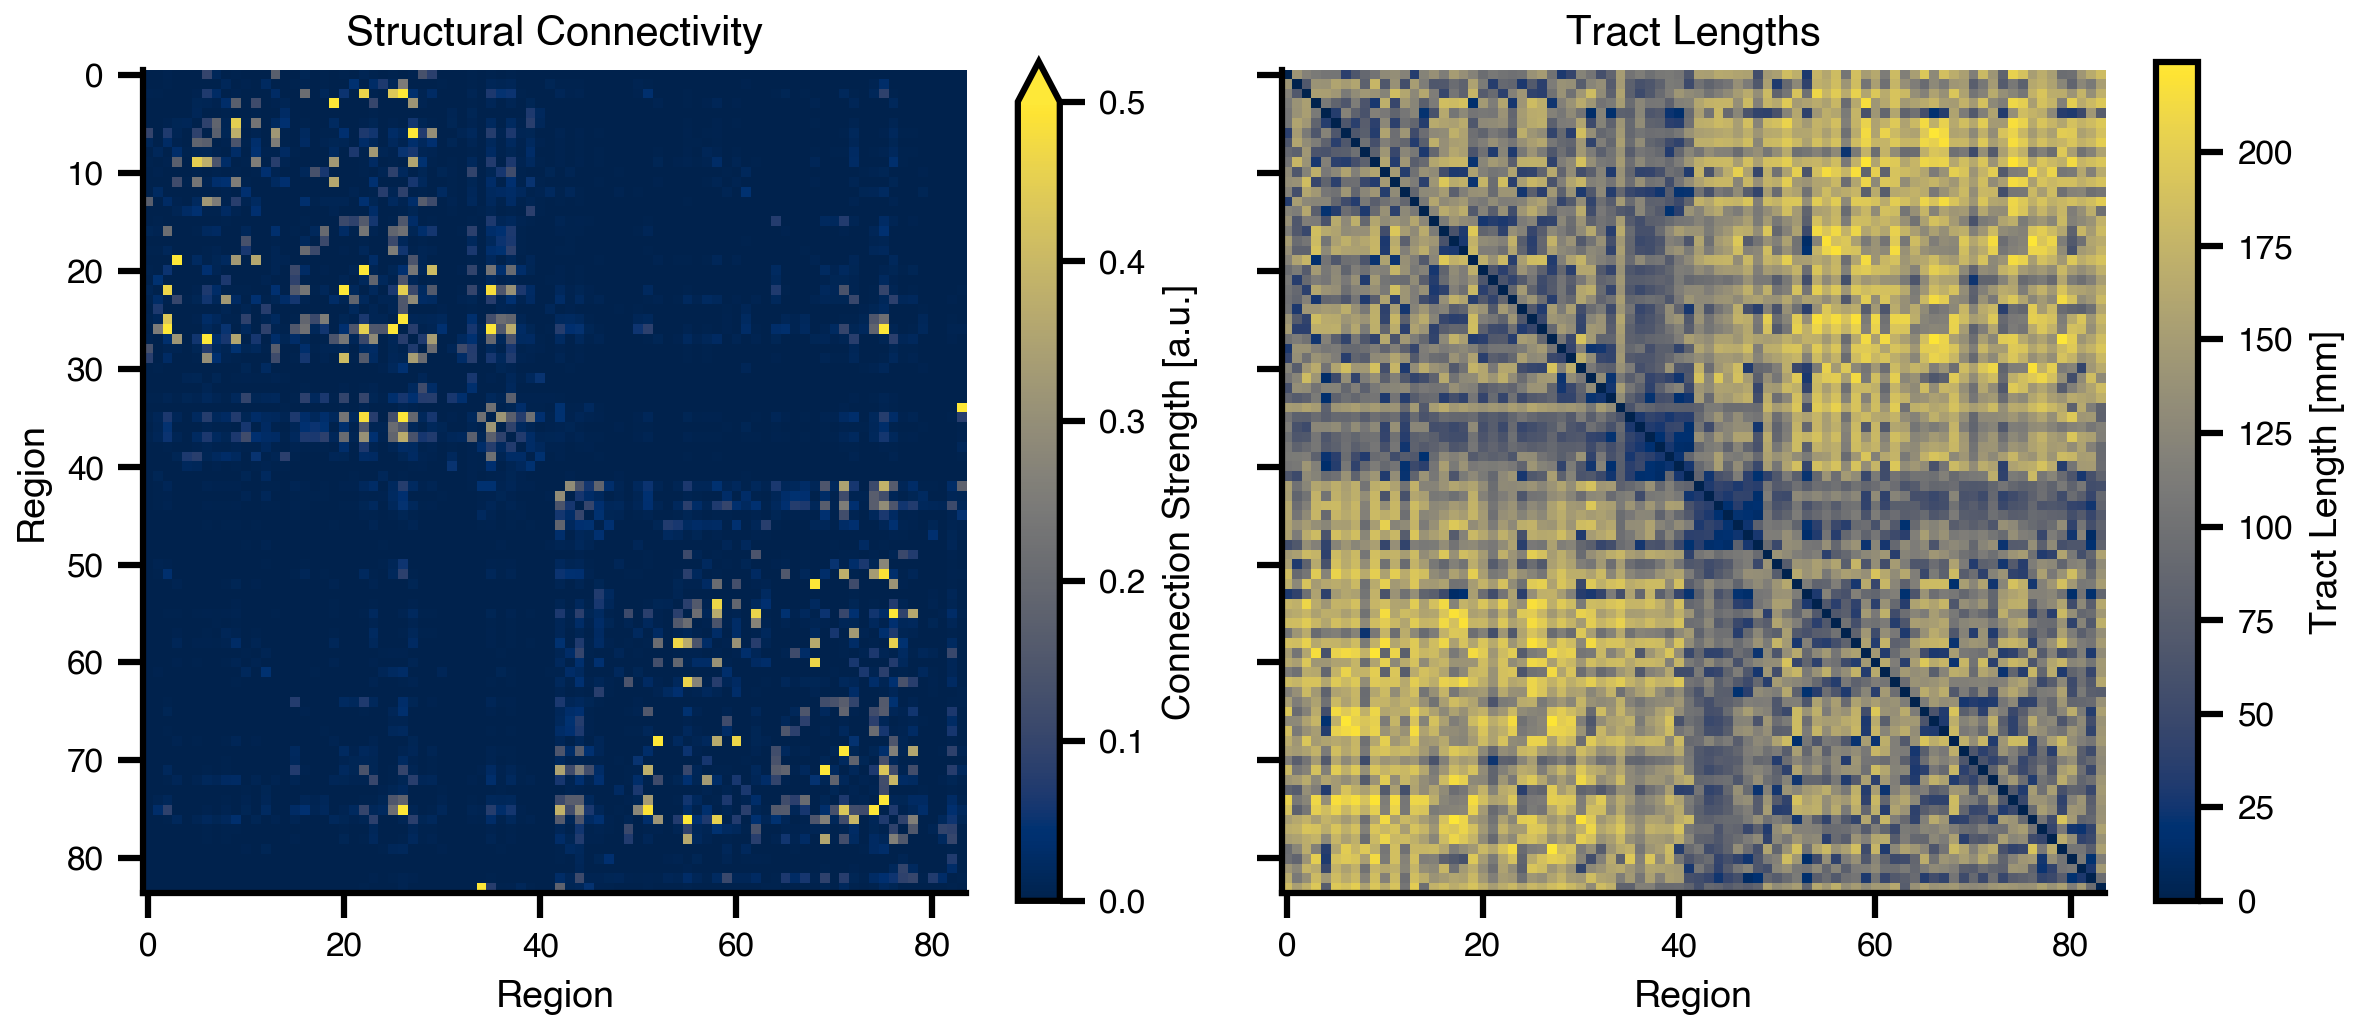

In [6]:
#| label: fig-connectivity
#| fig-cap: '**Structural connectivity matrices.** Left: Normalized connection weights showing the strength of white matter connections between brain regions. Right: Tract lengths in millimeters representing the physical distance of fiber pathways.'
#| code-fold: true
#| code-summary: Show plotting code

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 4.05), sharey=True)
im1 = ax1.imshow(weights, cmap="cividis", vmax=0.5)
ax1.set_title("Structural Connectivity")
ax1.set_xlabel("Region")
ax1.set_ylabel("Region")
cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.74, label="Connection Strength [a.u.]", extend='max')

im2 = ax2.imshow(lengths, cmap="cividis")
ax2.set_title("Tract Lengths")
ax2.set_xlabel("Region")
cbar2 = fig.colorbar(im2, ax=ax2, shrink=0.74, label="Tract Length [mm]")

plt.tight_layout()

In [7]:
#| echo: true
#| output: false

# Create network components
graph = DenseGraph(weights, region_labels=region_labels)
dynamics = ReducedWongWang(w=0.3, I_o=0.32, INITIAL_STATE=(0.3,))
coupling = FastLinearCoupling(local_states=["S"], G=0.15)
noise = AdditiveNoise(sigma=0.00283, apply_to="S")

# Assemble the network
network = Network(
    dynamics=dynamics,
    coupling={'instant': coupling},
    graph=graph,
    noise=noise
)

In [8]:
#| echo: true
# Prepare simulation: compile model and initialize state
t1 = 90_000  # Total simulation duration (ms) - 2 minutes
dt = 4.0      # Integration timestep (ms)
model, state = prepare(network, Heun(), t1=t1, dt=dt)

# First simulation: run transient to reach quasi-stationary state
result_init = model(state)

# Update network with final state as new initial conditions
network.update_history(result_init)
model, state = prepare(network, Heun(), t1=t1, dt=dt)

# Second simulation: quasi-stationary dynamics
result = model(state)

In [9]:
#| echo: true
# Create BOLD monitor with standard parameters
bold_monitor = Bold(
    period=1000.0,          # BOLD sampling period (1 TR = 1000 ms)
    downsample_period=4.0,  # Intermediate downsampling matches dt
    voi=0,                  # Monitor first state variable (S)
    history=result_init     # Use initial state as warm start
)

# Apply BOLD monitor to simulation result
bold_result = bold_monitor(result)

/var/folders/ym/9kw1g21j1nd7kwfn8c0z3st40000gn/T/ipykernel_33908/2955482924.py:2: DeprecationWarning: Bold is deprecated and will be removed in a future version. Use HRFBold (HRF convolution) or BalloonWindkesselBold (ODE integration) explicitly.
  bold_monitor = Bold(


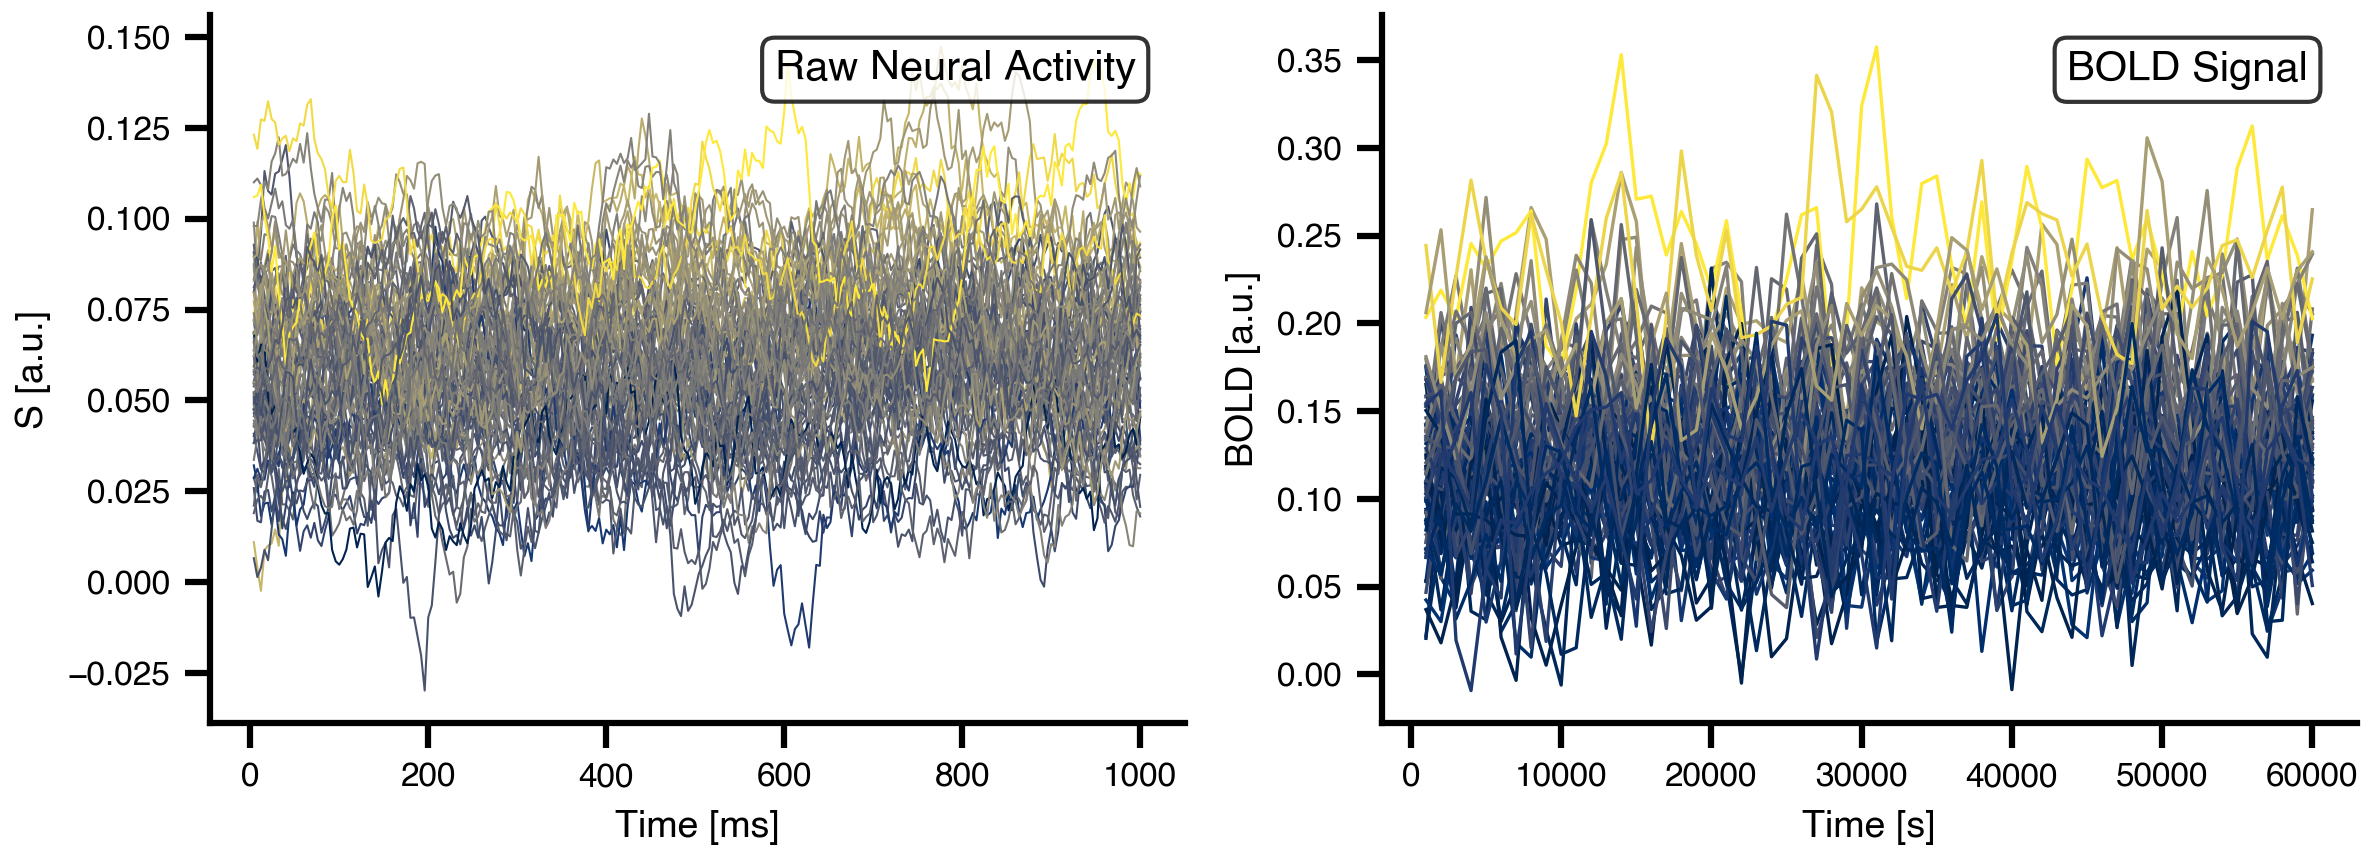

In [10]:
#| label: fig-timeseries
#| fig-cap: '**Neural activity and BOLD signal time series.** Left: Raw synaptic gating variable (S) showing fast neural dynamics over 1 second. Right: Simulated BOLD signal showing slow hemodynamic response over 60 seconds. Each line represents one brain region, colored by mean activity level.'
#| code-fold: true
#| code-summary: Show plotting code

from matplotlib.colors import Normalize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 3.0375))

# Plot raw neural activity (first 1000 ms)
t_max_idx = int(1000 / dt)
time_raw = result.time[:t_max_idx]
data_raw = result.data[:t_max_idx, 0, :]

num_lines = data_raw.shape[1]
cmap = plt.cm.cividis
mean_values = np.mean(data_raw, axis=0)
norm = Normalize(vmin=np.min(mean_values), vmax=np.max(mean_values))
for i in range(num_lines):
    color = cmap(norm(mean_values[i]))
    ax1.plot(time_raw, data_raw[:, i], color=color, linewidth=0.5)

ax1.text(0.95, 0.95, "Raw Neural Activity", transform=ax1.transAxes, fontsize=10,
         ha='right', va='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("S [a.u.]")

# Plot BOLD signal (first 60 TRs)
t_bold_max = 60
time_bold = bold_result.time[:t_bold_max]
data_bold = bold_result.data[:t_bold_max, 0, :]

num_lines = data_bold.shape[1]
mean_values = np.mean(data_bold, axis=0)
norm = Normalize(vmin=np.min(mean_values), vmax=np.max(mean_values))
for i in range(num_lines):
    color = cmap(norm(mean_values[i]))
    ax2.plot(time_bold, data_bold[:, i], color=color, linewidth=0.8)

ax2.text(0.95, 0.95, "BOLD Signal", transform=ax2.transAxes, fontsize=10,
         ha='right', va='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("BOLD [a.u.]")

plt.tight_layout()

In [11]:
#| echo: true

def observation(state):
    """Compute functional connectivity from simulated BOLD signal."""
    # Run simulation
    result = model(state)
    # Convert to BOLD
    bold = bold_monitor(result)
    # Compute FC, skipping first 20 TRs to avoid transient effects
    fc = compute_fc(bold, skip_t=20)
    return fc

def loss(state):
    """Compute RMSE between simulated and empirical FC."""
    fc = observation(state)
    return rmse(fc, fc_target)

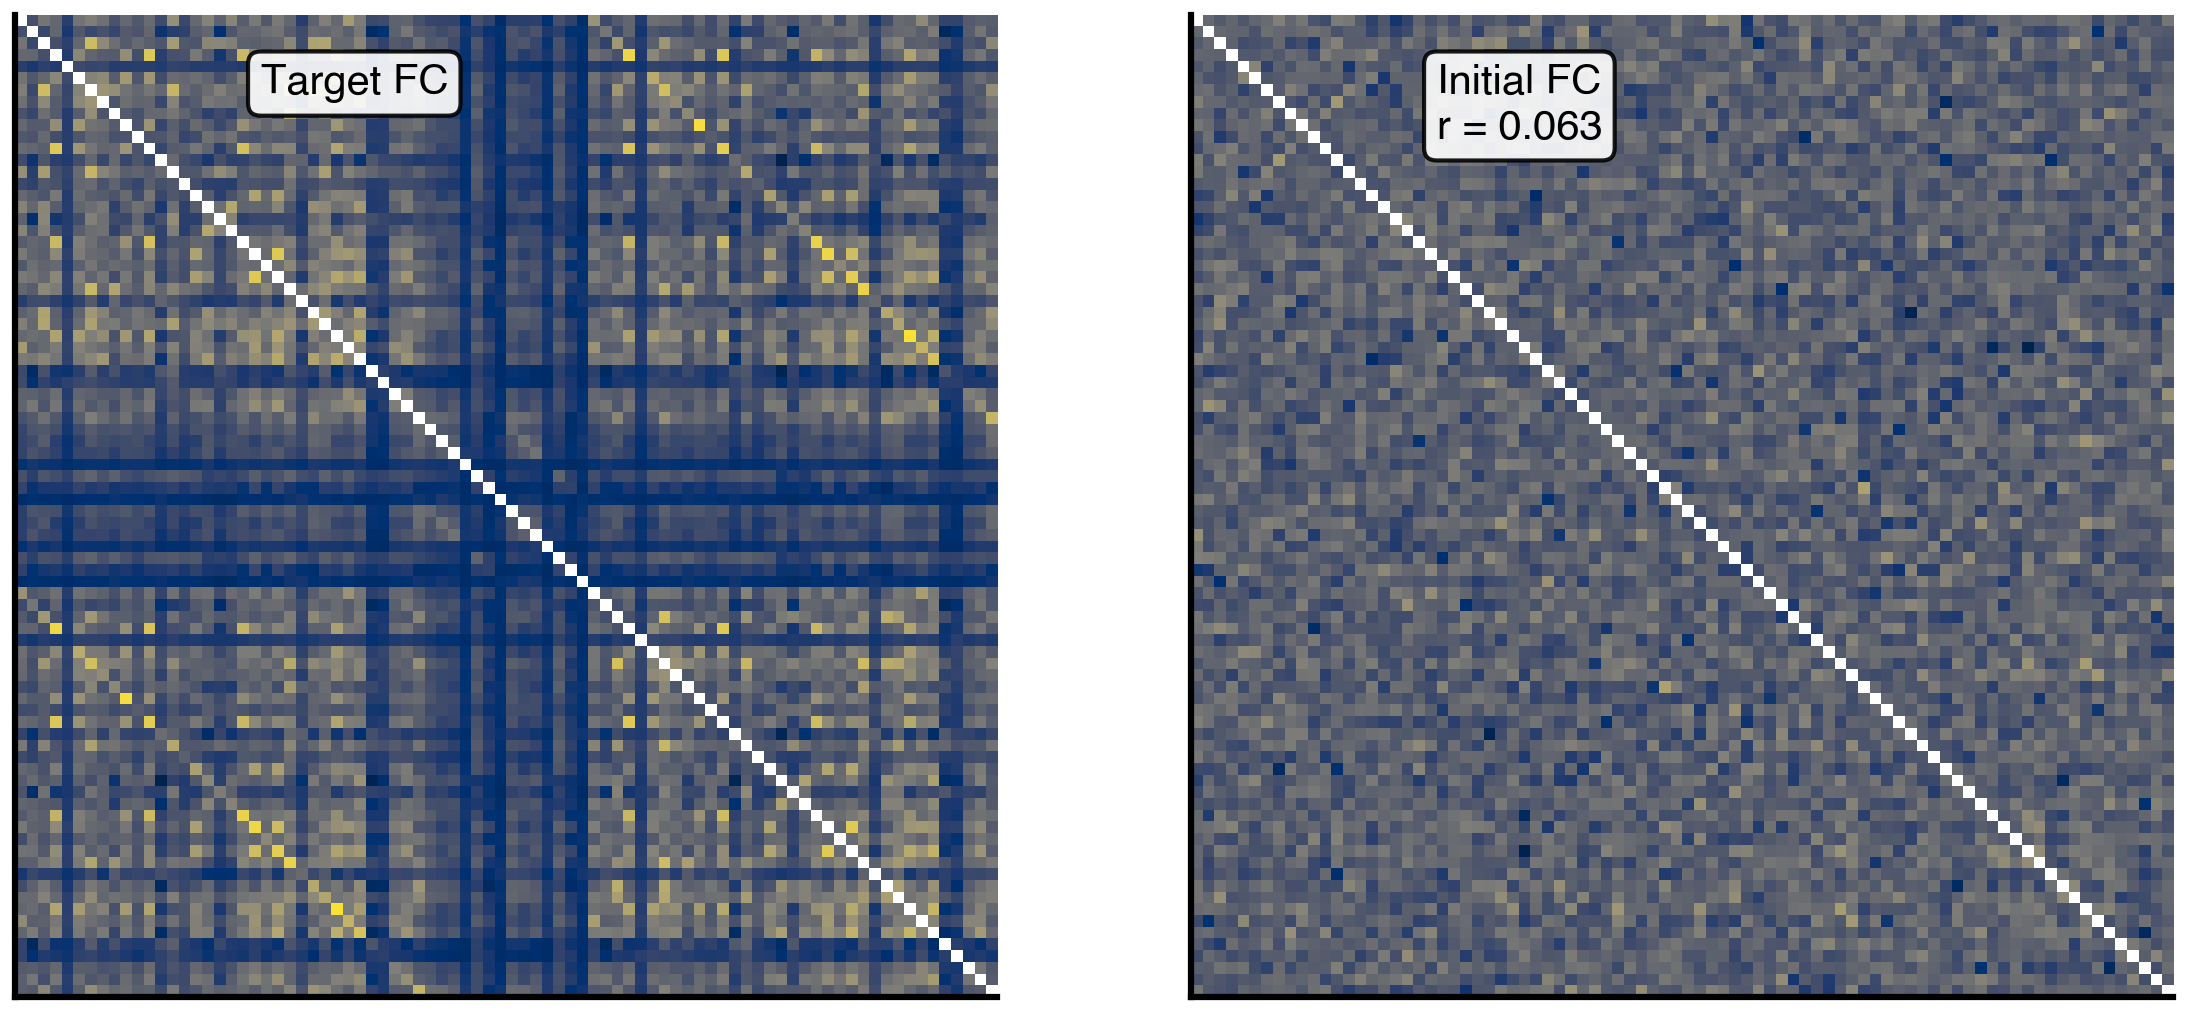

In [12]:
#| label: fig-initial-fc
#| fig-cap: '**Initial functional connectivity comparison.** Left: Empirical FC from resting-state fMRI serving as optimization target. Right: Simulated FC from initial model parameters showing poor correlation with target (r = correlation coefficient between the two matrices).'
#| code-fold: true
#| code-summary: Show plotting code

# Calculate initial FC
fc_initial = np.array(observation(state))

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 3.54375))

# Plot both FC matrices
for ax_current, fc_matrix, title_prefix in zip([ax1, ax2], [fc_target, fc_initial], ["Target FC", "Initial FC"]):
    fc_matrix = np.copy(fc_matrix)
    np.fill_diagonal(fc_matrix, np.nan)  # Set diagonal to NaN
    im = ax_current.imshow(fc_matrix, cmap='cividis', vmax=0.9)

    ax_current.set_xticks([])
    ax_current.set_yticks([])
    ax_current.set_xlabel('')
    ax_current.set_ylabel('')

    # Calculate correlation for title
    if title_prefix == "Initial FC":
        corr_value = fc_corr(fc_initial, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"
    else:
        title = title_prefix

    # Add title as annotation
    ax_current.annotate(title,
                       xy=(0.25, 0.95),
                       xycoords='axes fraction',
                       ha='left', va='top',
                       fontsize=10, fontweight='bold',
                       color='black',
                       bbox=dict(boxstyle='round,pad=0.3',
                                facecolor='white', alpha=0.9))

plt.tight_layout()

In [13]:
#| echo: true
#| output: false

# Create grid for parameter exploration
n = 16

# Replace scalar values with GridAxis(...) to mark them as sweep axes:
# each axis defines `n` linearly spaced values to try.
grid_state = copy.deepcopy(state)
grid_state.dynamics.w = GridAxis(0.001, 0.7, n)
grid_state.coupling.instant.G = GridAxis(0.001, 0.7, n)

# Space wraps the state into an iterable of all parameter combinations.
# mode="product" -> Cartesian product (n*n = 256 evaluations);
# mode="zip" would pair axes element-wise instead (n evaluations).
grid = Space(grid_state, mode="product")

# @cache stores the function's return value on disk under the given key.
# On rerun, the cached result is loaded instead of recomputing. Set redo=True # to force recomputation if you change anything upstream (e.g. the loss).
@cache("explore", redo=False)
def explore():
    # n_pmap=8 maps evaluations across 8 JAX devices in parallel — this matches
    # the XLA_FLAGS device count set at the top of the notebook.
    exec = ParallelExecution(loss, grid, n_pmap=8)
    # Alternative: Sequential execution (RAM friendlier)
    # exec = SequentialExecution(loss, grid)
    return exec.run()

exploration_results = explore()

Loading explore from cache, last modified 2026-05-10 09:17:55.947886


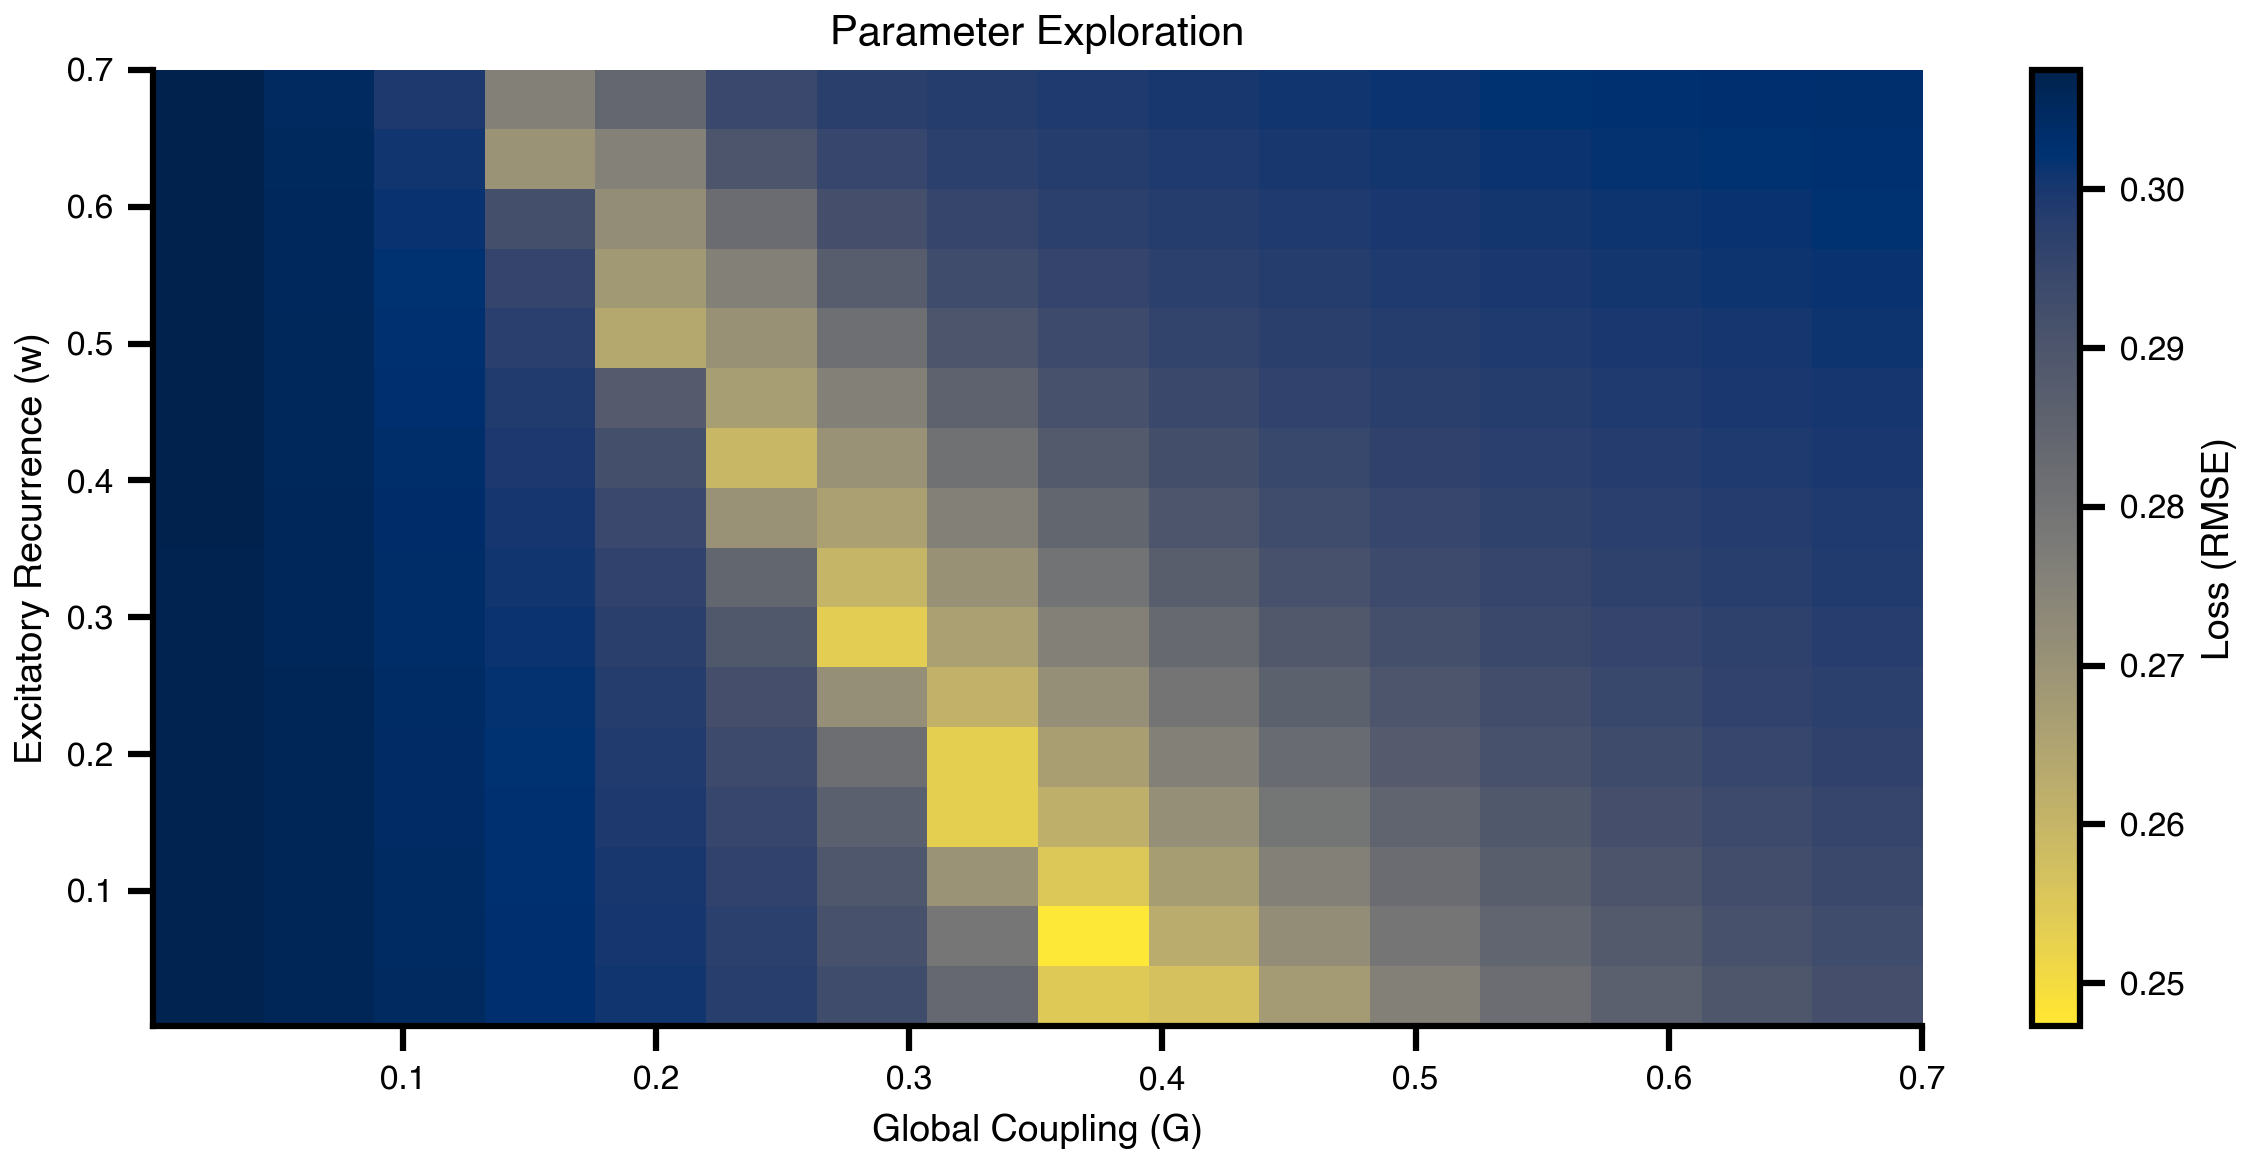

In [14]:
#| label: fig-exploration
#| fig-cap: '**Parameter landscape exploration.** The heatmap shows FC fitting loss (RMSE) across the parameter space of excitatory recurrence (w) and global coupling (G). Dark regions indicate better FC fits. The landscape reveals an optimal region where both parameters balance to reproduce empirical connectivity patterns.'
#| code-fold: true
#| code-summary: Show plotting code

# Long-form table of (G, w, loss) triples — pivot into a 2D matrix
# indexed by w (rows) and G (columns) for plotting.
df_grid = exploration_results.to_dataframe()
loss_grid = df_grid.pivot(index='dynamics.w', columns='coupling.instant.G', values='value')

G_vals = loss_grid.columns.values
w_vals = loss_grid.index.values
G_min, G_max = G_vals.min(), G_vals.max()
w_min, w_max = w_vals.min(), w_vals.max()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8.1, 4.05))

# Create the heatmap
im = ax.imshow(loss_grid.values,
              cmap='cividis_r',
              extent=[G_min, G_max, w_min, w_max],
              origin='lower',
              aspect='auto',
              interpolation='none')

# Add colorbar and labels
cbar = plt.colorbar(im, label="Loss (RMSE)")
ax.set_xlabel('Global Coupling (G)')
ax.set_ylabel('Excitatory Recurrence (w)')
ax.set_title("Parameter Exploration")

plt.tight_layout()

In [15]:
#| echo: true
#| output: false

# Wrap values in Parameter(...) to mark them as optimizable. The optimizer
# walks the state tree, finds every Parameter, computes gradients w.r.t. the
# loss, and updates them in place. Values left as plain floats stay fixed.
state.coupling.instant.G = Parameter(state.coupling.instant.G)
state.dynamics.w = Parameter(state.dynamics.w)

# Create and run optimizer
cb = MultiCallback([
    DefaultPrintCallback(every=10),
    SavingCallback(key="state", save_fun=lambda *args: args[1])  # Save updated state on every iteration for visualization
])

@cache("optimize", redo=False)
def optimize():
    opt = OptaxOptimizer(loss, optax.adam(0.01), callback=cb)
    fitted_state, fitting_data = opt.run(state, max_steps=100)
    return fitted_state, fitting_data

fitted_state, fitting_data = optimize()

Loading optimize from cache, last modified 2026-05-10 09:17:56.017249


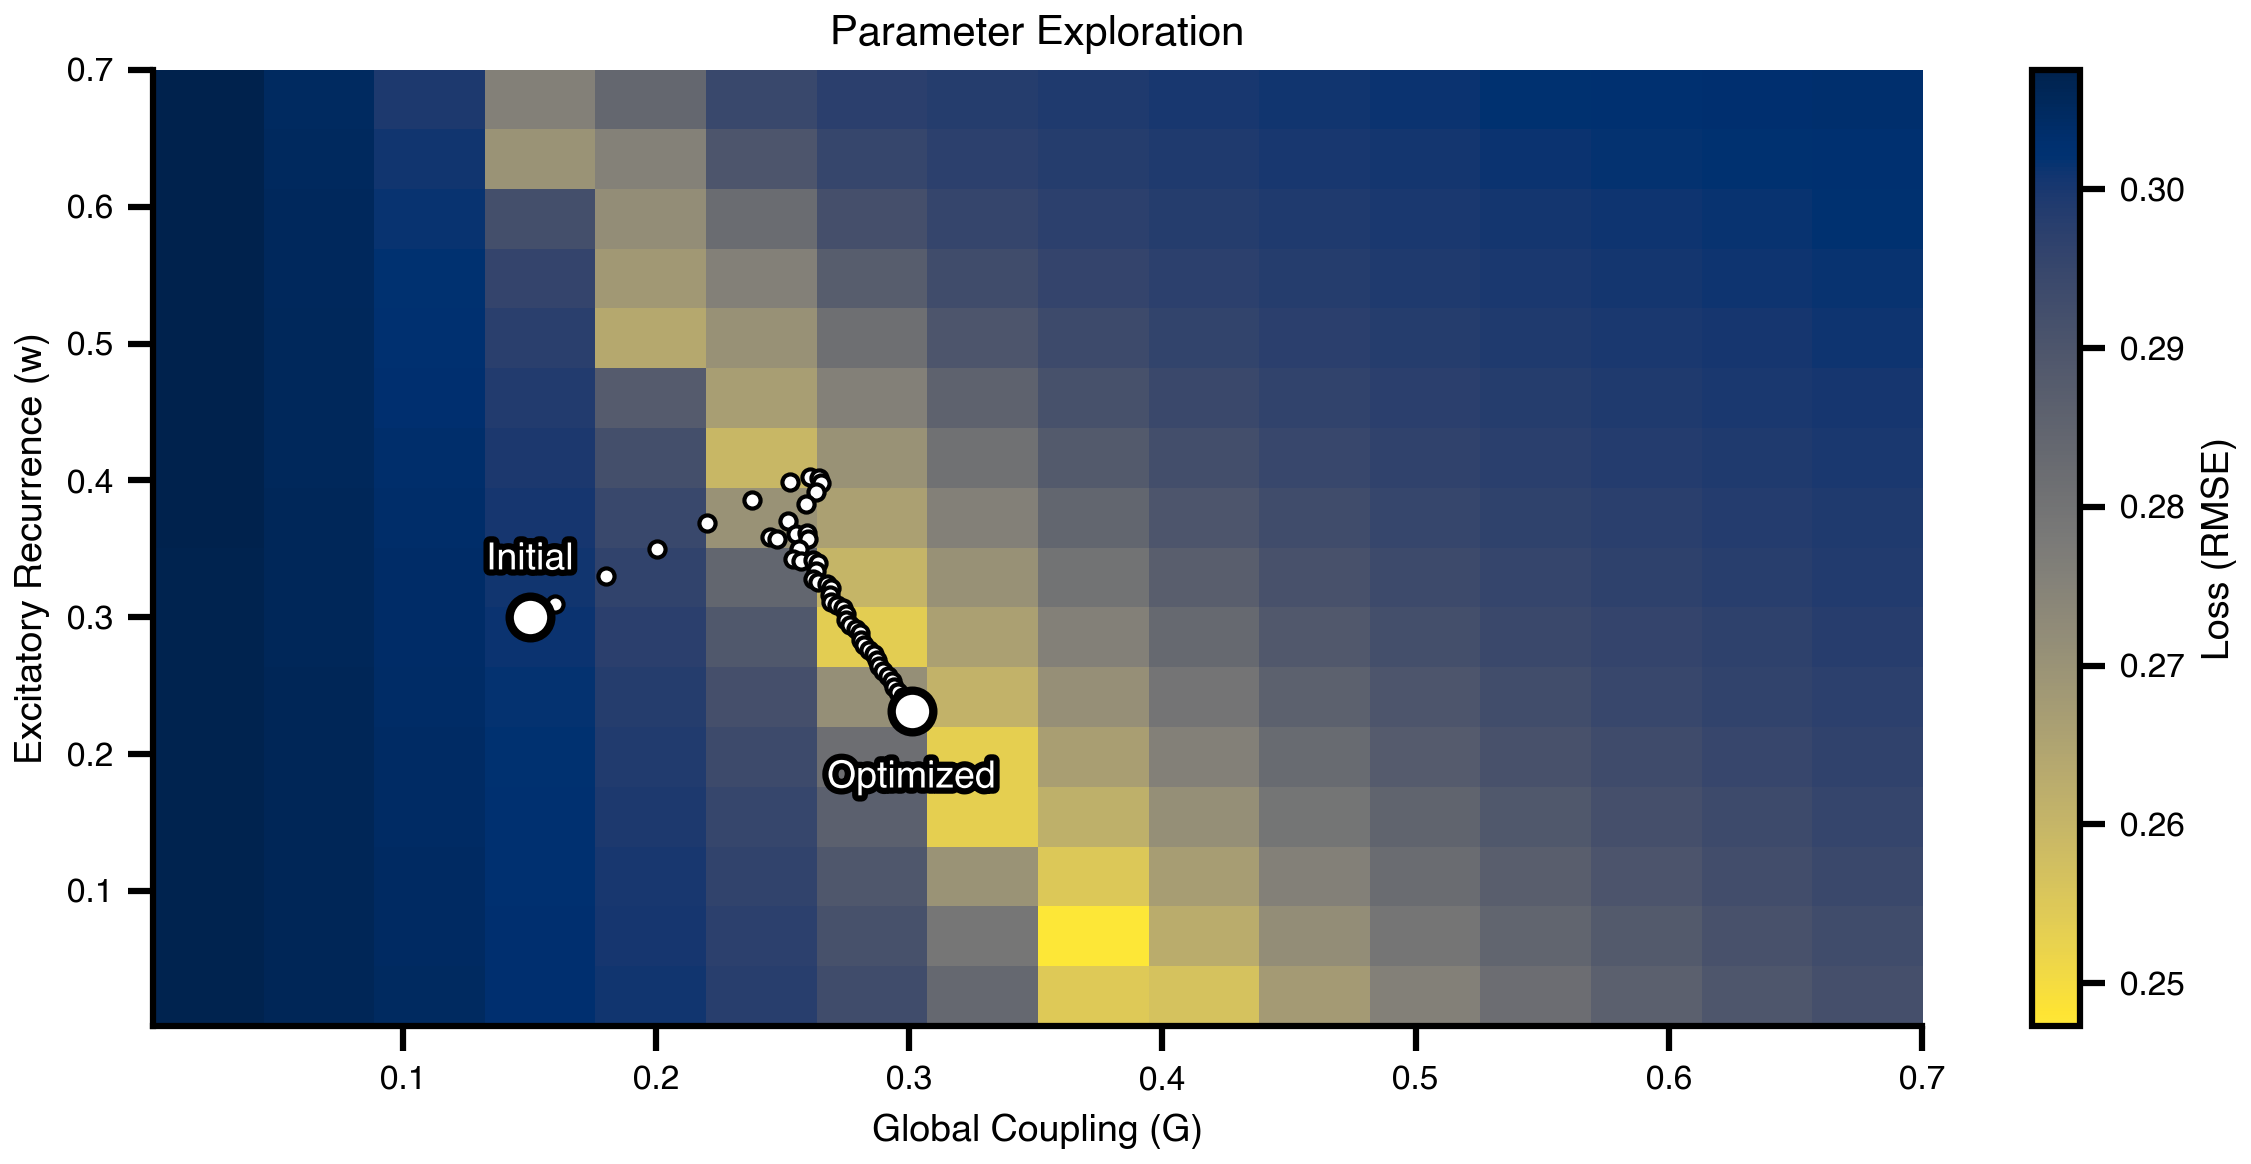

In [16]:
#| label: fig-optimization-trajectory
#| fig-cap: '**Optimization trajectory in parameter space.** White points show the path taken by gradient descent from initial parameters (top marker) to optimized values (bottom marker). The optimizer efficiently navigates the loss landscape to find parameter combinations that yield good FC fits.'
#| code-fold: true
#| code-summary: Show plotting code

# Same pivot trick as in the exploration plot above.
df_grid = exploration_results.to_dataframe()
loss_grid = df_grid.pivot(index='dynamics.w', columns='coupling.instant.G', values='value')

G_vals = loss_grid.columns.values
w_vals = loss_grid.index.values
G_min, G_max = G_vals.min(), G_vals.max()
w_min, w_max = w_vals.min(), w_vals.max()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8.1, 4.05))

# Create the heatmap
im = ax.imshow(loss_grid.values,
              cmap='cividis_r',
              extent=[G_min, G_max, w_min, w_max],
              origin='lower',
              aspect='auto',
              interpolation='none')

# Mark initial value
G_init = state.coupling.instant.G.value
w_init = state.dynamics.w.value
ax.scatter(G_init, w_init, color='white', s=100, marker='o',
           edgecolors='k', linewidths=2, zorder=5)

# Add annotation
ax.annotate('Initial', xy=(G_init, w_init),
            xytext=(G_init, w_init+0.05*(w_max-w_min)),
            color='white', fontweight='bold', ha='center', zorder=5,
            path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])

# Add fitted value point
G_fit = fitted_state.coupling.instant.G.value
w_fit = fitted_state.dynamics.w.value
ax.scatter(G_fit, w_fit, color='white', s=100, marker='o',
           edgecolors='k', linewidths=2, zorder=5)

# Add annotation for the fitted value
ax.annotate('Optimized', xy=(G_fit, w_fit),
            xytext=(G_fit, w_fit-0.08*(w_max-w_min)),
            color='white', fontweight='bold', ha='center', zorder=5,
            path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])

# Add optimization path points
G_route = np.array([ds.coupling.instant.G.value for ds in fitting_data["state"].save])
w_route = np.array([ds.dynamics.w.value for ds in fitting_data["state"].save])
ax.scatter(G_route[::2], w_route[::2], color='white', s=15, marker='o',
           linewidths=1, zorder=4, edgecolors='k')

# Add colorbar and labels
cbar = plt.colorbar(im, label="Loss (RMSE)")
ax.set_xlabel('Global Coupling (G)')
ax.set_ylabel('Excitatory Recurrence (w)')
ax.set_title("Parameter Exploration")

plt.tight_layout()

In [17]:
#| echo: true
# Copy the already-optimized state so the heterogeneous fit starts from
# the global optimum rather than from scratch.
fitted_state_het = copy.deepcopy(fitted_state)

# .shape = (n_nodes,) promotes the scalar w into a length-n_nodes vector,
# initialized by broadcasting the current value. Each region then gets its
# own gradient and is updated independently.
fitted_state_het.dynamics.w.shape = (n_nodes,)

# Unwrap G back to a plain value (Parameter -> .value) to freeze it during
# this fit. Only Parameter-wrapped fields get optimized.
fitted_state_het.coupling.instant.G = fitted_state_het.coupling.instant.G.value

show_parameters(fitted_state_het)

Parameters
├── _internal: Bunch
├── coupling: Bunch
├── dynamics
│   └── w
│       └── value: [0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327
 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327 0.2314327]
├── external: Bunch
├── graph: DenseGraph
├── initial

In [18]:
#| echo: true
#| output: false

@cache("optimize_het", redo=False)
def optimize_het():
    opt = OptaxOptimizer(loss, optax.adam(0.005), callback=cb)
    fitted_state, fitting_data = opt.run(fitted_state_het, max_steps=100)
    return fitted_state, fitting_data

fitted_state_het, fitting_data_het = optimize_het()

Loading optimize_het from cache, last modified 2026-05-10 09:17:56.090749


In [19]:
#| output: false
#| echo: true
# Compute FC for both optimization strategies
fc_global = np.array(observation(fitted_state))
fc_regional = np.array(observation(fitted_state_het))

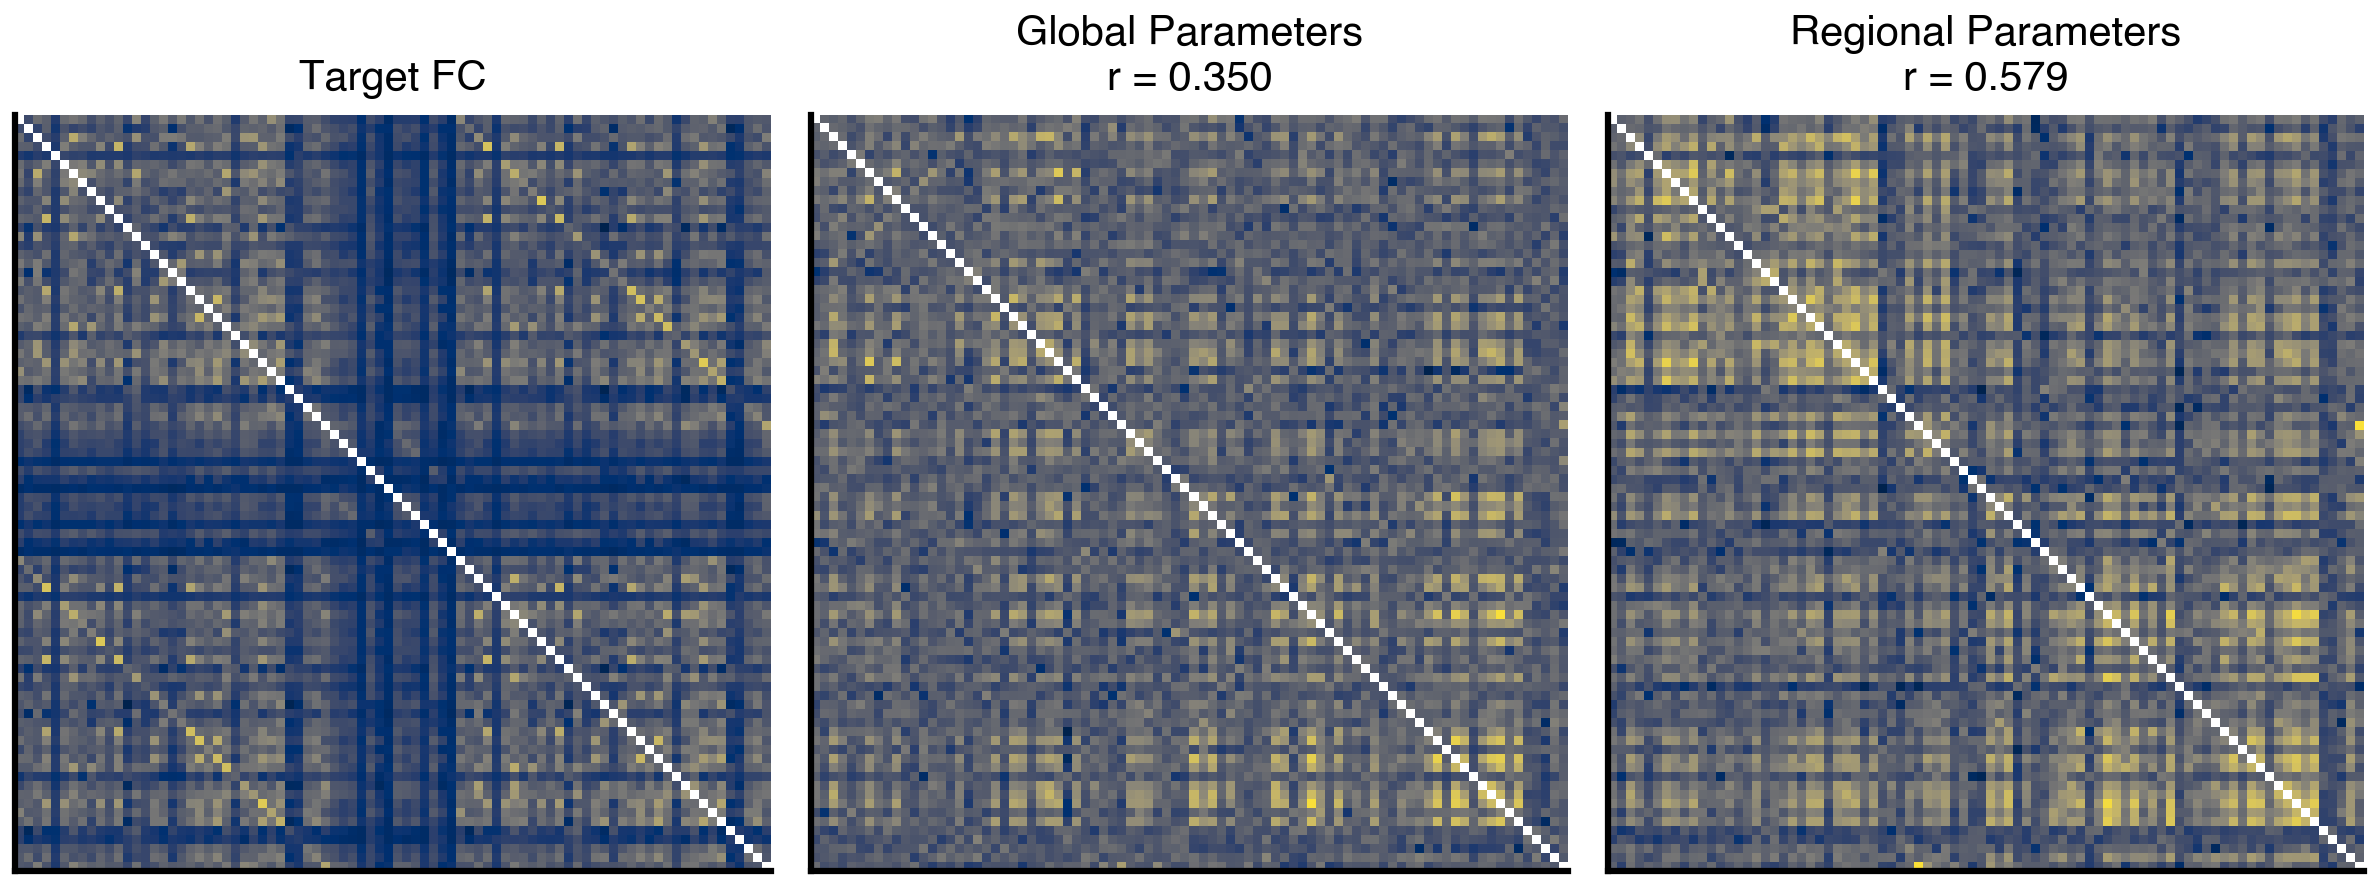

In [20]:
#| label: fig-fc-comparison
#| fig-cap: '**Comparison of functional connectivity matrices.** Left: Empirical target FC from resting-state fMRI. Middle: FC from global parameter optimization. Right: FC from regional parameter optimization. The correlation coefficient (r) quantifies the similarity to the target FC. Regional parameters achieve better fit by accounting for local variations.'
#| code-fold: true
#| code-summary: Show plotting code

# Create the figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8.1, 3.54375))

# Plot the FC matrices
for ax_current, fc_matrix, title_prefix in zip([ax1, ax2, ax3], [fc_target, fc_global, fc_regional], ["Target FC", "Global Parameters", "Regional Parameters"]):
    fc_matrix = np.copy(fc_matrix)
    np.fill_diagonal(fc_matrix, np.nan)  # Set diagonal to NaN
    im = ax_current.imshow(fc_matrix, cmap='cividis', vmax=1.0)

    ax_current.set_xticks([])
    ax_current.set_yticks([])
    ax_current.set_xlabel('')
    ax_current.set_ylabel('')

    # Calculate correlation for title (if not target)
    if title_prefix == "Target FC":
        title = title_prefix
    elif title_prefix == "Global Parameters":
        corr_value = fc_corr(fc_global, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"
    else:
        corr_value = fc_corr(fc_regional, fc_target)
        title = f"{title_prefix}\nr = {corr_value:.3f}"

    # Set title
    ax_current.set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()

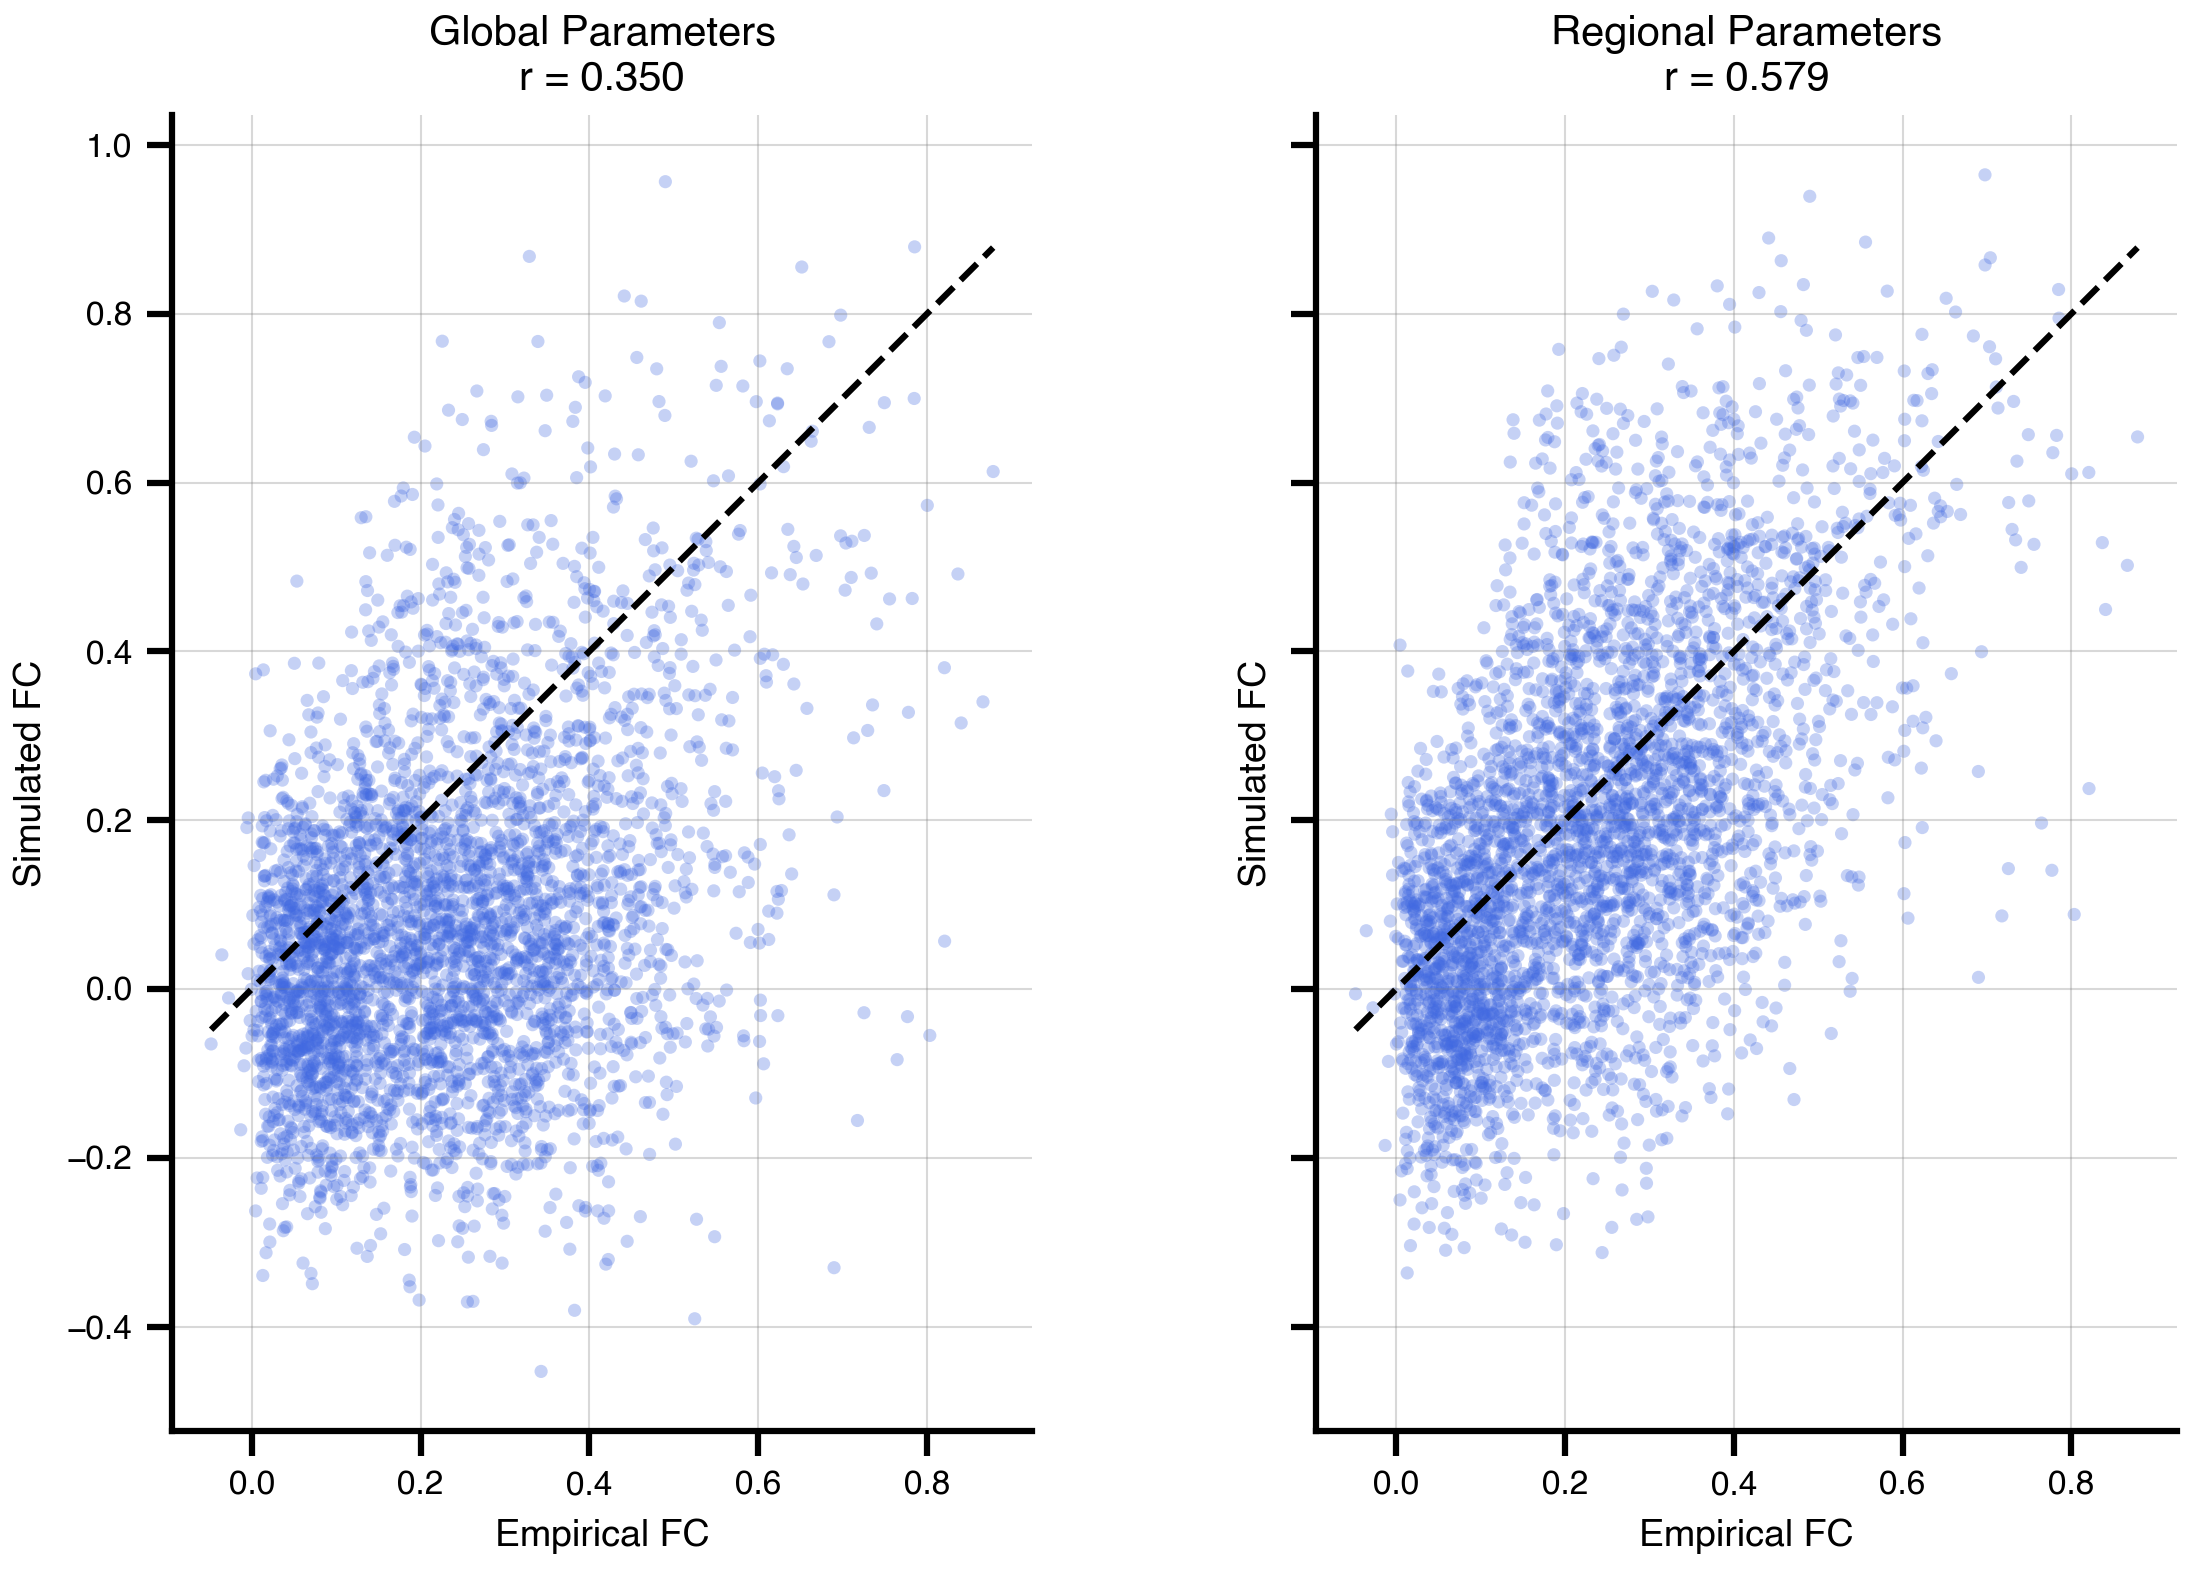

In [21]:
#| label: fig-fc-scatter
#| fig-cap: '**Scatter plots comparing fitted vs empirical FC.** Each point represents one pairwise connection between brain regions. Left: Global parameter fit shows good overall correlation. Right: Regional parameter fit shows improved correlation with reduced scatter, indicating better reproduction of the empirical FC structure. The diagonal line represents perfect agreement.'
#| code-fold: true
#| code-summary: Show plotting code

# Create figure with two scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.1, 5.4), sharey=True, sharex=True)

# Get upper triangular indices (exclude diagonal)
triu_idx = np.triu_indices_from(fc_target, k=1)

# Extract upper triangular values
fc_target_triu = fc_target[triu_idx]
fc_global_triu = fc_global[triu_idx]
fc_regional_triu = fc_regional[triu_idx]

# Plot global parameters
ax1.scatter(fc_target_triu, fc_global_triu, alpha=0.3, s=10, color='royalblue', edgecolors='none')
ax1.plot([fc_target_triu.min(), fc_target_triu.max()],
         [fc_target_triu.min(), fc_target_triu.max()],
         'k--', linewidth=1.5, label='Perfect fit')
corr_global = fc_corr(fc_global, fc_target)
ax1.set_xlabel('Empirical FC')
ax1.set_ylabel('Simulated FC')
ax1.set_title(f'Global Parameters\nr = {corr_global:.3f}')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Plot regional parameters
ax2.scatter(fc_target_triu, fc_regional_triu, alpha=0.3, s=10, color='royalblue', edgecolors='none')
ax2.plot([fc_target_triu.min(), fc_target_triu.max()],
         [fc_target_triu.min(), fc_target_triu.max()],
         'k--', linewidth=1.5, label='Perfect fit')
corr_regional = fc_corr(fc_regional, fc_target)
ax2.set_xlabel('Empirical FC')
ax2.set_ylabel('Simulated FC')
ax2.set_title(f'Regional Parameters\nr = {corr_regional:.3f}')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()

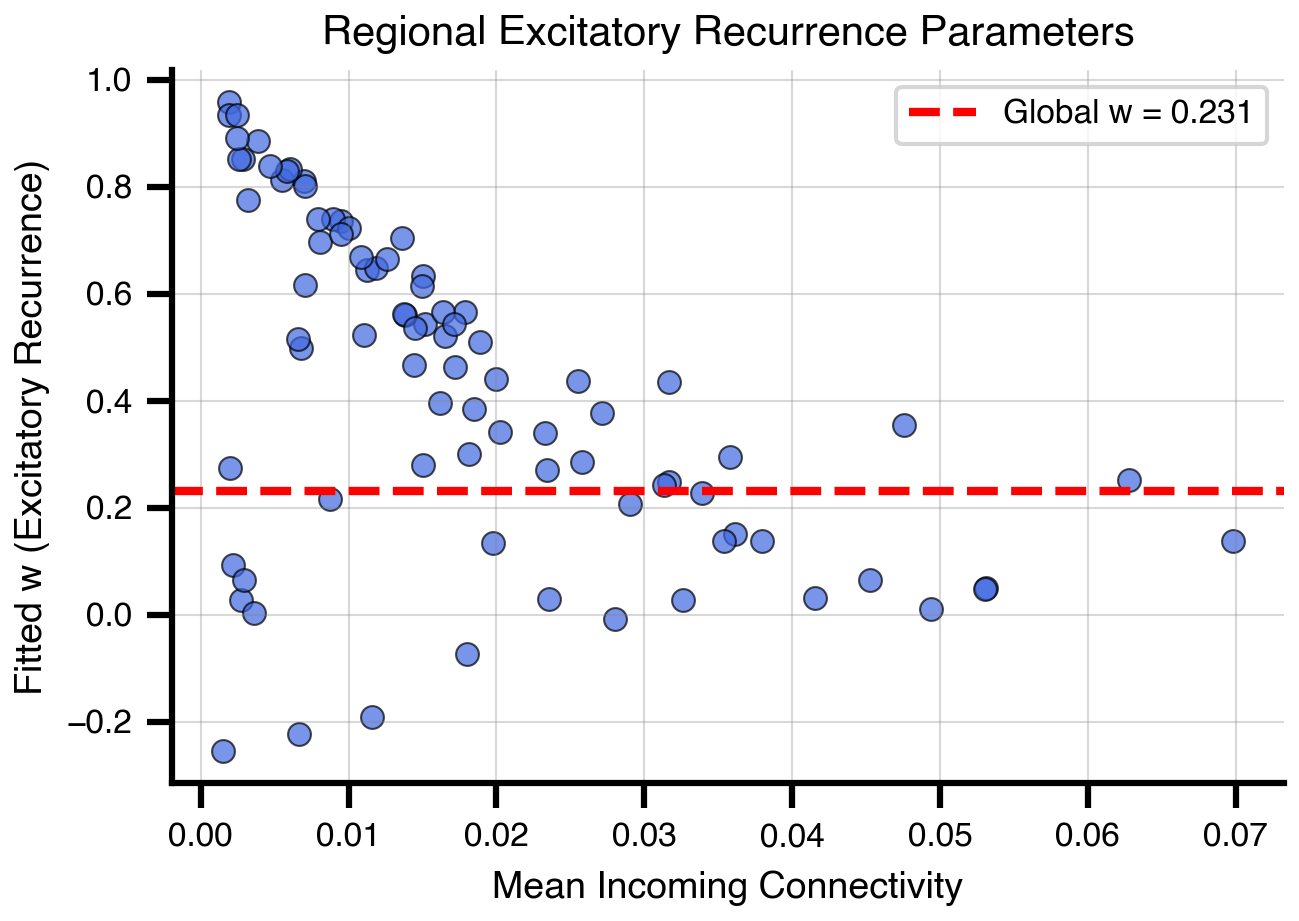

In [22]:
#| label: fig-fitted-params
#| fig-cap: '**Fitted heterogeneous parameters.** Fitted excitatory recurrence (w) for each region plotted against mean incoming structural connectivity strength. The dashed line shows the global optimization value for reference. Regions with stronger structural connections tend to require different parameter values to achieve optimal FC fit, demonstrating the importance of region-specific tuning.'
#| code-fold: true
#| code-summary: Show plotting code

# Calculate mean incoming connectivity for each region
mean_connectivity = np.mean(weights, axis=1)

# Extract fitted regional parameters
w_fitted = fitted_state_het.dynamics.w.value.flatten()

# Get global optimization values for reference
w_global = fitted_state.dynamics.w.value

# Create figure
fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 3.24))

# Plot w vs mean connectivity
ax1.scatter(mean_connectivity, w_fitted, alpha=0.7, s=30, color='royalblue', edgecolors='k', linewidths=0.5)
ax1.axhline(w_global, color='red', linestyle='--', linewidth=2, label=f'Global w = {w_global:.3f}')
ax1.set_xlabel('Mean Incoming Connectivity')
ax1.set_ylabel('Fitted w (Excitatory Recurrence)')
ax1.set_title('Regional Excitatory Recurrence Parameters')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

plt.tight_layout()